# LLM Validation Workflow

This notebook evaluates LLM labeling quality against human validation labels. It does not call Groq and does not create artificial human labels.

If no human labels exist yet, it creates a sample CSV for teammates to fill and emits placeholder output files that clearly state validation is pending.


In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "backend"))

from app.analysis.targets import normalize_target

DB_PATH = PROJECT_ROOT / "backend" / "data" / "twstock_sentiment.db"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_CSV_CANDIDATES = [
    TABLE_DIR / "human_validation_filled.csv",
    TABLE_DIR / "human_validation_sample.csv",
    TABLE_DIR / "validation_sample.csv",
]
SAMPLE_OUTPUT = TABLE_DIR / "human_validation_sample.csv"
SUMMARY_OUTPUT = TABLE_DIR / "llm_validation_summary.csv"
MISCLASSIFIED_OUTPUT = TABLE_DIR / "llm_misclassified_examples.csv"
ACCURACY_FIGURE = FIGURE_DIR / "llm_validation_accuracy.png"
CONFUSION_FIGURE = FIGURE_DIR / "llm_validation_confusion_matrix.png"

sns.set_theme(style="whitegrid")


## Load Human Validation Data

Priority:

1. `human_validation` table, if populated.
2. A filled CSV such as `outputs/tables/human_validation_filled.csv`.
3. Existing sample CSV files. Rows without human labels are treated as pending, not as incorrect.


In [2]:
def clean_label(value):
    if pd.isna(value):
        return ""
    return str(value).strip()

with sqlite3.connect(DB_PATH) as conn:
    human_db = pd.read_sql_query("SELECT * FROM human_validation", conn)
    sample_source = pd.read_sql_query(
        """
        SELECT
            n.id AS news_id,
            n.title,
            n.url,
            a.news_type AS llm_news_type,
            a.target AS llm_target,
            a.sentiment AS llm_sentiment,
            a.confidence,
            a.reason,
            '' AS human_news_type,
            '' AS human_target,
            '' AS human_sentiment,
            '' AS note
        FROM raw_news n
        JOIN llm_news_analysis a ON a.news_id = n.id
        WHERE a.status = 'success'
        ORDER BY random()
        LIMIT 100
        """,
        conn,
    )

if not human_db.empty:
    validation = human_db.copy()
    validation["source"] = "human_validation_table"
else:
    csv_path = next((path for path in VALIDATION_CSV_CANDIDATES if path.exists()), None)
    if csv_path is not None:
        validation = pd.read_csv(csv_path, encoding="utf-8-sig")
        validation["source"] = csv_path.name
    else:
        validation = pd.DataFrame()

if validation.empty or not {"human_news_type", "human_sentiment"}.issubset(validation.columns):
    sample_source.to_csv(SAMPLE_OUTPUT, index=False, encoding="utf-8-sig")
    validation = sample_source.copy()
    validation["source"] = SAMPLE_OUTPUT.name
elif validation[["human_news_type", "human_sentiment"]].fillna("").eq("").all().all():
    # Refresh the sample when the currently available CSV is still blank.
    sample_source.to_csv(SAMPLE_OUTPUT, index=False, encoding="utf-8-sig")

for col in ["human_news_type", "human_target", "human_sentiment", "llm_news_type", "llm_target", "llm_sentiment"]:
    if col not in validation.columns:
        validation[col] = ""
    validation[col] = validation[col].map(clean_label)

validation["human_target_normalized"] = validation.apply(lambda row: normalize_target(row.get("human_news_type"), row.get("human_target")) or "", axis=1)
validation["llm_target_normalized"] = validation.apply(lambda row: normalize_target(row.get("llm_news_type"), row.get("llm_target")) or "", axis=1)
validation["has_type_label"] = validation["human_news_type"] != ""
validation["has_sentiment_label"] = validation["human_sentiment"] != ""
validation["has_target_label"] = validation["human_target"] != ""
validation["has_all_labels"] = validation["has_type_label"] & validation["has_sentiment_label"] & validation["has_target_label"]

print(f"validation rows loaded: {len(validation):,}")
print(f"labeled news_type rows: {validation['has_type_label'].sum():,}")
print(f"labeled sentiment rows: {validation['has_sentiment_label'].sum():,}")
print(f"labeled target rows: {validation['has_target_label'].sum():,}")
print(f"sample CSV for teammates: {SAMPLE_OUTPUT}")
display(validation.head())


validation rows loaded: 100
labeled news_type rows: 0
labeled sentiment rows: 0
labeled target rows: 0
sample CSV for teammates: C:\python_data_analysis_final\outputs\tables\human_validation_sample.csv


,news_id,title,url,llm_news_type,llm_target,llm_sentiment,confidence,reason,human_news_type,human_target,...,type_correct,sentiment_correct,note,source,human_target_normalized,llm_target_normalized,has_type_label,has_sentiment_label,has_target_label,has_all_labels
0,651,尋台積電外第二代工商？蘋果傳接觸Intel、三星,https://tw.stock.yahoo.com/news/%E5%B0%8B%E5%8...,industry,semiconductor industry,neutral,0.8,新聞主要討論業界動態，未表明明確的正面或負面情緒,,,...,NaN,NaN,NaN,human_validation_sample.csv,,SEMICONDUCTOR INDUSTRY,False,False,False,False
1,22,CHERY品牌官宣羅伯特•萊萬多夫斯基出任全球代言人 深化「For Family」全球品牌表達,https://tw.stock.yahoo.com/news/chery%E5%93%81...,industry,,neutral,0.8,新聞主要介紹了CHERY品牌與羅伯特•萊萬多夫斯基的合作關係，沒有明顯的正面或負面情緒表達,,,...,NaN,NaN,NaN,human_validation_sample.csv,,,False,False,False,False
2,549,聯強 115年第1季綜合損益表，每股盈餘1.77元,https://tw.stock.yahoo.com/news/%E8%81%AF%E5%B...,stock,2347,neutral,0.8,新聞主要介紹聯強的財務報表，沒有明顯的正面或負面情緒,,,...,NaN,NaN,NaN,human_validation_sample.csv,,2347,False,False,False,False
3,501,台積電下周一「一根向下招待」？專家：營收月減震盪難免 恐回測10到20元,https://tw.stock.yahoo.com/news/%E5%8F%B0%E7%A...,stock,2330,negative,0.8,文章提到台積電營收月減1.1%，並且有可能回測10到20元,,,...,NaN,NaN,NaN,human_validation_sample.csv,,2330,False,False,False,False
4,515,美伊和談生變數！台股早盤跌129點、台積電開2300元,https://tw.stock.yahoo.com/news/%E7%BE%8E%E4%B...,market,TAIEX/0050,negative,0.8,新聞中提到台股下跌129點,,,...,NaN,NaN,NaN,human_validation_sample.csv,,0050,False,False,False,False


## Accuracy Metrics

Accuracy is computed only over rows with corresponding human labels. Pending rows are excluded.


In [3]:
def accuracy(mask, pred_col, truth_col):
    subset = validation[mask].copy()
    if subset.empty:
        return pd.NA, 0
    return float((subset[pred_col] == subset[truth_col]).mean()), len(subset)

type_acc, type_n = accuracy(validation["has_type_label"], "llm_news_type", "human_news_type")
sentiment_acc, sentiment_n = accuracy(validation["has_sentiment_label"], "llm_sentiment", "human_sentiment")
target_acc, target_n = accuracy(validation["has_target_label"], "llm_target_normalized", "human_target_normalized")
exact_subset = validation[validation["has_all_labels"]].copy()
if exact_subset.empty:
    exact_acc, exact_n = pd.NA, 0
else:
    exact_match = (
        (exact_subset["llm_news_type"] == exact_subset["human_news_type"])
        & (exact_subset["llm_sentiment"] == exact_subset["human_sentiment"])
        & (exact_subset["llm_target_normalized"] == exact_subset["human_target_normalized"])
    )
    exact_acc, exact_n = float(exact_match.mean()), len(exact_subset)

summary = pd.DataFrame([
    {"metric": "news_type_accuracy", "accuracy": type_acc, "sample_size": type_n},
    {"metric": "sentiment_accuracy", "accuracy": sentiment_acc, "sample_size": sentiment_n},
    {"metric": "target_accuracy", "accuracy": target_acc, "sample_size": target_n},
    {"metric": "overall_exact_match_accuracy", "accuracy": exact_acc, "sample_size": exact_n},
])
summary.to_csv(SUMMARY_OUTPUT, index=False, encoding="utf-8-sig")
summary


,metric,accuracy,sample_size
0,news_type_accuracy,<NA>,0
1,sentiment_accuracy,<NA>,0
2,target_accuracy,<NA>,0
3,overall_exact_match_accuracy,<NA>,0


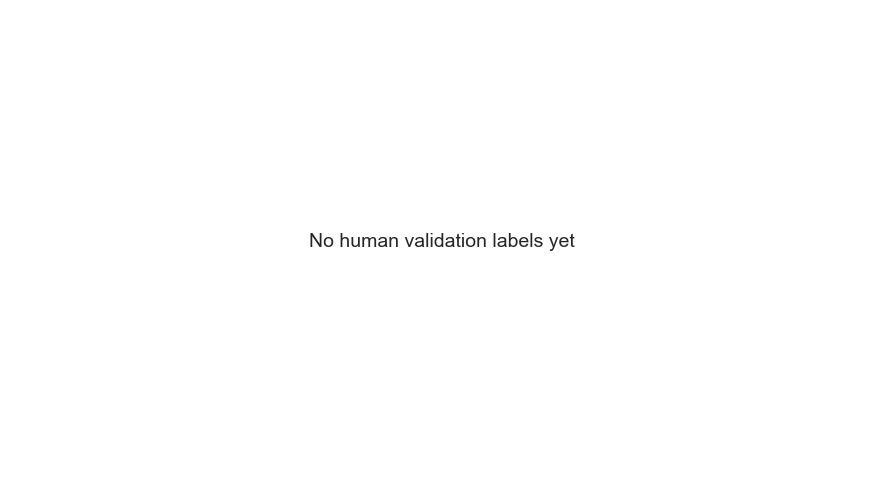

In [4]:
plot_summary = summary.dropna(subset=["accuracy"])
fig, ax = plt.subplots(figsize=(9, 5))
if plot_summary.empty:
    ax.text(0.5, 0.5, "No human validation labels yet", ha="center", va="center", fontsize=14)
    ax.set_axis_off()
else:
    sns.barplot(data=plot_summary, x="metric", y="accuracy", ax=ax, color="#4c78a8")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Accuracy")
    ax.set_title("LLM Validation Accuracy")
    ax.tick_params(axis="x", rotation=25)
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(ACCURACY_FIGURE, dpi=160)
plt.show()


## Confusion Matrices

The figure contains news type and sentiment confusion matrices when human labels are available.


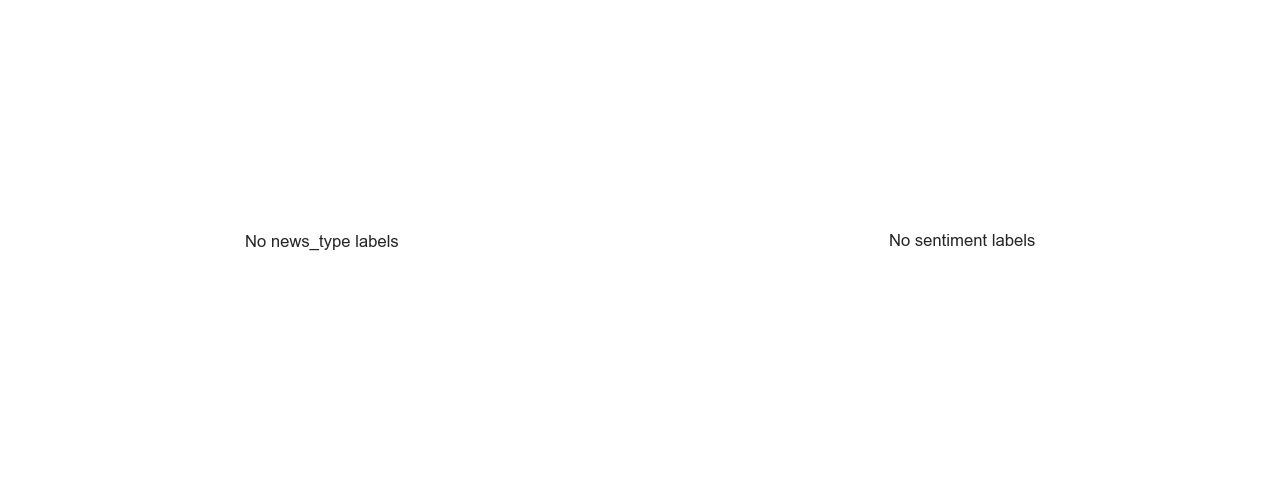

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if validation["has_type_label"].any():
    type_matrix = pd.crosstab(validation.loc[validation["has_type_label"], "human_news_type"], validation.loc[validation["has_type_label"], "llm_news_type"])
    sns.heatmap(type_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title("News Type Confusion Matrix")
    axes[0].set_xlabel("LLM")
    axes[0].set_ylabel("Human")
else:
    axes[0].text(0.5, 0.5, "No news_type labels", ha="center", va="center")
    axes[0].set_axis_off()

if validation["has_sentiment_label"].any():
    sentiment_matrix = pd.crosstab(validation.loc[validation["has_sentiment_label"], "human_sentiment"], validation.loc[validation["has_sentiment_label"], "llm_sentiment"])
    sns.heatmap(sentiment_matrix, annot=True, fmt="d", cmap="Greens", ax=axes[1])
    axes[1].set_title("Sentiment Confusion Matrix")
    axes[1].set_xlabel("LLM")
    axes[1].set_ylabel("Human")
else:
    axes[1].text(0.5, 0.5, "No sentiment labels", ha="center", va="center")
    axes[1].set_axis_off()

fig.tight_layout()
fig.savefig(CONFUSION_FIGURE, dpi=160)
plt.show()


## Misclassified Examples

Rows are included when any labeled field disagrees with the LLM output. If no labels exist yet, the output table is empty.


In [6]:
validation["news_type_correct"] = (~validation["has_type_label"]) | (validation["llm_news_type"] == validation["human_news_type"])
validation["sentiment_correct"] = (~validation["has_sentiment_label"]) | (validation["llm_sentiment"] == validation["human_sentiment"])
validation["target_correct"] = (~validation["has_target_label"]) | (validation["llm_target_normalized"] == validation["human_target_normalized"])
validation["has_any_label"] = validation[["has_type_label", "has_sentiment_label", "has_target_label"]].any(axis=1)

misclassified = validation[
    validation["has_any_label"]
    & (~validation["news_type_correct"] | ~validation["sentiment_correct"] | ~validation["target_correct"])
].copy()

columns = [
    "news_id", "title", "url",
    "human_news_type", "llm_news_type",
    "human_target", "llm_target", "human_target_normalized", "llm_target_normalized",
    "human_sentiment", "llm_sentiment",
    "confidence", "reason", "note",
]
for col in columns:
    if col not in misclassified.columns:
        misclassified[col] = ""
misclassified[columns].to_csv(MISCLASSIFIED_OUTPUT, index=False, encoding="utf-8-sig")
misclassified[columns].head(30)


,news_id,title,url,human_news_type,llm_news_type,human_target,llm_target,human_target_normalized,llm_target_normalized,human_sentiment,llm_sentiment,confidence,reason,note


## Output Files


In [7]:
for path in [SUMMARY_OUTPUT, MISCLASSIFIED_OUTPUT, ACCURACY_FIGURE, CONFUSION_FIGURE, SAMPLE_OUTPUT]:
    print(f"{path}: {path.exists()} ({path.stat().st_size if path.exists() else 0} bytes)")


C:\python_data_analysis_final\outputs\tables\llm_validation_summary.csv: True (131 bytes)
C:\python_data_analysis_final\outputs\tables\llm_misclassified_examples.csv: True (175 bytes)
C:\python_data_analysis_final\outputs\figures\llm_validation_accuracy.png: True (13716 bytes)
C:\python_data_analysis_final\outputs\figures\llm_validation_confusion_matrix.png: True (15746 bytes)
C:\python_data_analysis_final\outputs\tables\human_validation_sample.csv: True (46085 bytes)


## Conclusion


In [8]:
notes = []
if summary["sample_size"].sum() == 0:
    notes.append("No human validation labels are available yet, so model accuracy cannot be estimated without guessing.")
    notes.append(f"A 100-row sample CSV has been prepared for teammates at `{SAMPLE_OUTPUT}`. Fill `human_news_type`, `human_target`, and `human_sentiment`, then rerun this notebook.")
    notes.append("Until human labels are filled, downstream sentiment-return and backtest results should be treated as provisional.")
else:
    values = {row.metric: row.accuracy for row in summary.itertuples(index=False)}
    notes.append(f"News type accuracy is {values.get('news_type_accuracy'):.1%} on labeled rows." if pd.notna(values.get('news_type_accuracy')) else "News type accuracy is unavailable.")
    notes.append(f"Sentiment accuracy is {values.get('sentiment_accuracy'):.1%} on labeled rows." if pd.notna(values.get('sentiment_accuracy')) else "Sentiment accuracy is unavailable.")
    notes.append(f"Target accuracy is {values.get('target_accuracy'):.1%} on labeled rows." if pd.notna(values.get('target_accuracy')) else "Target accuracy is unavailable.")
    if misclassified.empty:
        notes.append("No labeled misclassifications were found in the current validation set.")
    else:
        common_errors = []
        for label, correct_col in [("news_type", "news_type_correct"), ("target", "target_correct"), ("sentiment", "sentiment_correct")]:
            error_count = int((validation["has_any_label"] & ~validation[correct_col]).sum())
            common_errors.append(f"{label}: {error_count}")
        notes.append("Observed error counts by field: " + ", ".join(common_errors) + ".")
    notes.append("Use these validation results as a reliability check for the sentiment-return and backtest notebooks, not as investment evidence.")

for note in notes:
    display(Markdown(f"- {note}"))


- No human validation labels are available yet, so model accuracy cannot be estimated without guessing.

- A 100-row sample CSV has been prepared for teammates at `C:\python_data_analysis_final\outputs\tables\human_validation_sample.csv`. Fill `human_news_type`, `human_target`, and `human_sentiment`, then rerun this notebook.

- Until human labels are filled, downstream sentiment-return and backtest results should be treated as provisional.